In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# importing all the necessary libraries

import seaborn as sns
from matplotlib import pyplot as plt
from numpy import mean
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Input data
data=pd.read_csv("../input/creditcardfraud/creditcard.csv")
data.head()

In [ ]:
data.dtypes

In [ ]:
data.isnull().sum()

In [ ]:
sns.countplot(x='Class', data = data)

#Counter is a container which stores the count of elements in a dictionary format where element is the key and its value corrosponds to it's count.
counter = Counter( data [ 'Class' ])
#passing 'Class' feature in the Counter , it tells no. of 1s and 0s present in the dataset
print(counter)

In [ ]:
print(data['Amount'].ndim)
print(data['Amount'].shape)

In [ ]:
ss= StandardScaler()
#Since all the features are already scaled (PCA dimesionality reduction) except Amount.
#create a new column Norm_Amount wherein Amount is scaled by Standard Scaler
data['Norm_Amount'] =  ss.fit_transform(np.array(data['Amount']).reshape(-1,1))

**Why reshape (-1 , 1 )?**

*Since fit_transform takes values in the form of ( n_samples , n_features ) and Amount feature has only 1D values (284807,) that's where reshape comes to rescue where -1 says let the rows be untouched and 1 says to add a column.*

In [ ]:
# Since transaction time doesn't play a part in deciding fraud credit card 
data.drop(columns=['Time' , 'Amount' ] , inplace =True)

In [ ]:
#check correaltion between different features with Class and Norm_Amount
plt.figure(figsize=(25,15))
sns.heatmap(data.corr() , cmap = 'coolwarm' , annot = True)

#V7 and V20 can be seen as in important feature w.r.t the amount transacted.

In [ ]:
# define y and X 
y = data['Class']
X = data.drop(['Class'] , axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.25 , random_state=42 , shuffle=False)

# **Why and where Repeated Startified KFold** ?

*Repeated Startified KFold - As the name says -repeating cross validation to get better , improved and accurate estimate of our machine learning model , a single run by the cross validation might result in noisy estimate of the model performance. It reports mean results across all folds from all runs.*

splits : 10
repeats : 3


**Since the dataset is imbalanced , we need to get it balanced to get accurate results which can be achieved by Oversampling the minority class or Undersampling the majority class . Since Undersampling looses out important information, we then tackle it by Oversampling method.**

**Oversampling comprises of two methods -**

1. Random OverSampling
2. SMOTE 

* Random Oversampling can be understood by an example -*Suppose you have a minority class having 100 samples and a majority class with 1000 samples . Say you pick up row 50 ( can be any ) and augment it on top of the minority class samples . You do this iteratively till it matches up the length of majority class.*

* Since **Random Oversampling** is just increasing the size but no variety in the train data . SMOTE on the other hand not just increases the size but also brings variety in the train data. Let's first understand what SMOTE is

* **Synthetic Minority OverSampling Technique** is abbreivated as **SMOTE** - general idea to carry out this technique is to bring the minority class values ( either 0 or 1 ) to a comparable number in terms of the other class . In other words to match up the length of the other class.

* But again one has to be careful on using SMOTE , when done right can be preferred over random oversampling . By right I mean - making newly synthetic samples legal. For example - the input for which legal values are animal and human ,there is nothing in between . This wont apply to an instance where input can be the weight of a human.

**HOW SMOTE WORKS**

1. The number of samples that need to be oversampled are set up - N.

2. We have X1 , X11 , X12 , X13 and X14 - Specify the k nearest neighbours you want to consider to create artficial samples - say 4 (k = 4)
 
* *SMOTE will find out the nearest neighbours of every point (X1 ,X11 ,...X14) . Based on number of samples you want SMOTE to create , SMOTE would first find out the lines adjoining of minority class samples to the k nearest neighbours you have considered and it will plot these instances somewhere on these lines. You can have multiple instances on a single line all depends on what you configurte and how many data points you want*

3. After synthesizing the new minority instances, the imbalance that existed in the dataset would go down considerably. Ratio becomes 1:1  ( equal no.. of 0s and 1s). Wuhuu..!!

 **WE ARE ALL SET TO BUILD A MODEL NOW.!!!**



![](http://)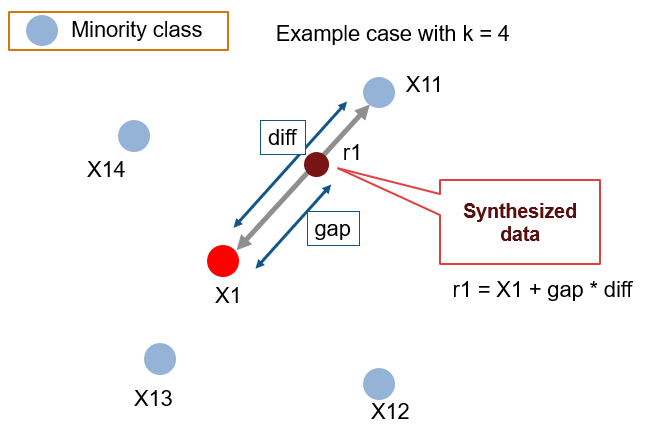

# **BEFORE SMOTE**
* We get ROC_AUC score of 0.881 before SMOTE.* 

**ROC_AUC-**

* *We choose ROC_AUC curve as it is the best evaluation metric for classification problems as it provides us with a degree of separability a model could harness.*  
 


In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train , y_train.ravel())
y_pred=model.predict(X_test)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
print('Mean ROC AUC: %.3f' % mean(scores))

# **BORDERLINE SMOTE WITH KNN**

* We use the same model same evaluation method , although use a SMOTE transformed version of the dataset. We can update the example to first oversample the minority class to have 10 percent the number of examples of the majority class (e.g. about 1,000), then use random undersampling to reduce the number of examples in the majority class to have 50 percent more than the minority class (e.g. about 2,000).

* In the SMOTE function -> sampling_strategy = 0.1 

* In the RandomUnderSampler -> sampling_strategy = 0.5

In [ ]:
# we make a list ok k values for k-nearest- neighbours and through iterating over the list of k values we find at which k we get the maximum ROC AUC score
k_values = [1, 2, 3, 4, 5, 6, 7]
for k in k_values:
    over = SMOTE(sampling_strategy=0.1, k_neighbors=k)
    under = RandomUnderSampler(sampling_strategy=0.5)
    steps = [('over', over), ('under', under), ('model', model)]
    pipeline = Pipeline(steps=steps)
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
    score = mean(scores)
    print('> k=%d, Mean ROC AUC: %.3f' % (k, score))

* **We can see an improvement in the ROC AUC score , at k=7 -> 0.912 we get the highest ROC AUC score followed by k= 6,5,4.. and so on.**